<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/AMFormer_TONIoT_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# AMFormer settings
N_EPOCHS   = 100
BATCH_SIZE = 512
LR         = 1e-4
D_MODEL    = 128
N_HEADS    = 4
DEPTH      = 3
DROPOUT    = 0.2
PATIENCE   = 15

print("Config loaded.")

Config loaded.


In [2]:
# INSTALL

!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed.")

All packages installed.


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef
)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

if not torch.cuda.is_available():
    print("WARNING: No GPU detected.")
    DEVICE = "cpu"
else:
    DEVICE = "cuda"
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU confirmed : Tesla T4
VRAM          : 15.6 GB


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir, y_proba=None):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    kappa       = cohen_kappa_score(y_true, y_pred)

    # ROC-AUC (requires probability scores)
    roc_auc = None
    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
        except Exception as e:
            print(f"  ROC-AUC computation note: {e}")

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  F1 (macro)         : {f1_macro:.4f}")
    print(f"  F1 (weighted)      : {f1_weighted:.4f}")
    print(f"  Precision (macro)  : {prec_macro:.4f}")
    print(f"  Recall (macro)     : {rec_macro:.4f}")
    print(f"  MCC                : {mcc:.4f}")
    print(f"  Cohen's Kappa      : {kappa:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC (macro)    : {roc_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    # Per-class precision & recall bar chart
    prec_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per_class  = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class   = f1_score(y_true, y_pred, average=None, zero_division=0)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(label_names))
    w = 0.25
    ax.bar(x - w, prec_per_class, w, label="Precision", color="steelblue")
    ax.bar(x,     rec_per_class,  w, label="Recall",    color="darkorange")
    ax.bar(x + w, f1_per_class,   w, label="F1",        color="forestgreen")
    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} — Per-Class Precision / Recall / F1")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    prf_path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_prf.png")
    plt.savefig(prf_path, dpi=150)
    plt.show()
    print(f"Saved: {prf_path}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "mcc": mcc,
        "cohen_kappa": kappa,
        "roc_auc_macro": roc_auc,
    }

print("Evaluation helper ready (with ROC-AUC, MCC, Kappa, per-class P/R/F1).")

Evaluation helper ready (with ROC-AUC, MCC, Kappa, per-class P/R/F1).


In [7]:
# AMFormer MODEL DEFINITION (AAAI 2024)


class FeatureEmbedding(nn.Module):
    def __init__(self, n_features, d_model):
        super().__init__()
        self.embeddings = nn.Linear(1, d_model)
        self.feature_bias = nn.Parameter(torch.zeros(n_features, d_model))
        nn.init.xavier_uniform_(self.feature_bias.unsqueeze(0))

    def forward(self, x):
        # x: (batch, n_features) -> (batch, n_features, d_model)
        x = x.unsqueeze(-1)                    # (batch, n_feat, 1)
        x = self.embeddings(x)                 # (batch, n_feat, d_model)
        x = x + self.feature_bias.unsqueeze(0) # add per-feature bias
        return x


class AdditiveAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return out


class MultiplicativeAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.head_dim = d_model // n_heads
        self.n_heads = n_heads
        self.d_model = d_model

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.head_dim)

    def forward(self, x):
        B, N, D = x.shape
        Q = self.W_q(x).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.head_dim).transpose(1, 2)

        # Multiplicative interaction: element-wise product of Q and K
        # then aggregate via attention weights
        attn_scores = (Q * K).sum(dim=-1) / self.scale  # (B, heads, N)
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Weighted combination: use exponentiated multiplication
        out = attn_weights.unsqueeze(-1) * V  # (B, heads, N, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.W_o(out)


class AMFormerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.add_attn = AdditiveAttention(d_model, n_heads, dropout)
        self.mul_attn = MultiplicativeAttention(d_model, n_heads, dropout)

        self.gate = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.Sigmoid()
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Parallel additive + multiplicative attention
        add_out = self.add_attn(x)
        mul_out = self.mul_attn(x)

        # Gated fusion of both branches
        combined = torch.cat([add_out, mul_out], dim=-1)
        gate = self.gate(combined)
        fused = gate * add_out + (1 - gate) * mul_out

        x = self.norm1(x + fused)
        x = self.norm2(x + self.ffn(x))
        return x


class AMFormer(nn.Module):
    def __init__(self, n_features, num_classes, d_model=128,
                 n_heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.embedding = FeatureEmbedding(n_features, d_model)

        # CLS token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # Prompt tokens (learnable tokens to constrain interactions)
        n_prompts = min(n_features, 8)
        self.prompts = nn.Parameter(torch.randn(1, n_prompts, d_model) * 0.02)

        # Transformer blocks with additive + multiplicative attention
        self.blocks = nn.ModuleList([
            AMFormerBlock(d_model, n_heads, dropout) for _ in range(depth)
        ])

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.embedding(x)  # (B, n_feat, d_model)

        # Prepend CLS token and prompt tokens
        cls = self.cls_token.expand(B, -1, -1)
        prompts = self.prompts.expand(B, -1, -1)
        x = torch.cat([cls, prompts, x], dim=1)

        for block in self.blocks:
            x = block(x)

        # Use CLS token for classification
        cls_out = x[:, 0]
        return self.head(cls_out)


model = AMFormer(
    n_features=n_features,
    num_classes=num_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    depth=DEPTH,
    dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"AMFormer trainable params: {n_params:,}")
print("Model built successfully.")

AMFormer trainable params: 896,778
Model built successfully.


In [8]:
# AMFormer TRAINING

train_ds = TensorDataset(
    torch.tensor(X_train_s, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(
    torch.tensor(X_val_s, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long))
test_ds = TensorDataset(
    torch.tensor(X_test_s, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long))

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.CrossEntropyLoss()

print("Training AMFormer on TON-IoT...")
print(f"Config: d_model={D_MODEL}, depth={DEPTH}, n_heads={N_HEADS}, "
      f"lr={LR}, epochs={N_EPOCHS}")
print()

best_val_f1 = 0
best_state  = None
no_improve  = 0
t0 = time.time()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    val_acc = accuracy_score(all_true, all_preds)
    val_f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)

    print(f"  Epoch {epoch:03d}/{N_EPOCHS} | "
          f"Loss: {epoch_loss/len(train_dl):.4f} | "
          f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"  Early stopping at epoch {epoch} (best Val F1: {best_val_f1:.4f})")
        break

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
model.eval()

train_time = time.time() - t0
print(f"\nAMFormer training complete in {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"Best Val F1: {best_val_f1:.4f}")

Training AMFormer on TON-IoT...
Config: d_model=128, depth=3, n_heads=4, lr=0.0001, epochs=100

  Epoch 001/100 | Loss: 1.4896 | Val Acc: 0.5595 | Val F1: 0.4244
  Epoch 002/100 | Loss: 0.9656 | Val Acc: 0.6766 | Val F1: 0.5377
  Epoch 003/100 | Loss: 0.7789 | Val Acc: 0.7115 | Val F1: 0.5939
  Epoch 004/100 | Loss: 0.7158 | Val Acc: 0.7248 | Val F1: 0.6049
  Epoch 005/100 | Loss: 0.6921 | Val Acc: 0.7286 | Val F1: 0.5980
  Epoch 006/100 | Loss: 0.6749 | Val Acc: 0.7606 | Val F1: 0.6502
  Epoch 007/100 | Loss: 0.6620 | Val Acc: 0.7640 | Val F1: 0.6603
  Epoch 008/100 | Loss: 0.6330 | Val Acc: 0.7869 | Val F1: 0.6882
  Epoch 009/100 | Loss: 0.5933 | Val Acc: 0.7815 | Val F1: 0.6818
  Epoch 010/100 | Loss: 0.5721 | Val Acc: 0.8019 | Val F1: 0.7040
  Epoch 011/100 | Loss: 0.5507 | Val Acc: 0.8107 | Val F1: 0.7083
  Epoch 012/100 | Loss: 0.5337 | Val Acc: 0.8248 | Val F1: 0.7247
  Epoch 013/100 | Loss: 0.5183 | Val Acc: 0.8114 | Val F1: 0.7210
  Epoch 014/100 | Loss: 0.5022 | Val Acc: 0.83

Inference time : 1.58s for 42,209 samples
                (0.0375 ms per sample)

  AMFormer — Results
  Accuracy           : 0.8572
  F1 (macro)         : 0.7783
  F1 (weighted)      : 0.8572
  Precision (macro)  : 0.8140
  Recall (macro)     : 0.7700
  MCC                : 0.8372
  Cohen's Kappa      : 0.8362
  ROC-AUC (macro)    : 0.9764

              precision    recall  f1-score   support

    backdoor       0.93      0.95      0.94      4000
        ddos       0.81      0.86      0.83      4000
         dos       0.99      0.91      0.95      4000
   injection       0.55      0.76      0.64      4000
        mitm       0.54      0.16      0.25       209
      normal       1.00      1.00      1.00     10000
    password       0.64      0.51      0.57      4000
  ransomware       0.91      0.99      0.95      4000
    scanning       0.99      0.85      0.91      4000
         xss       0.78      0.71      0.74      4000

    accuracy                           0.86     42209
   mac

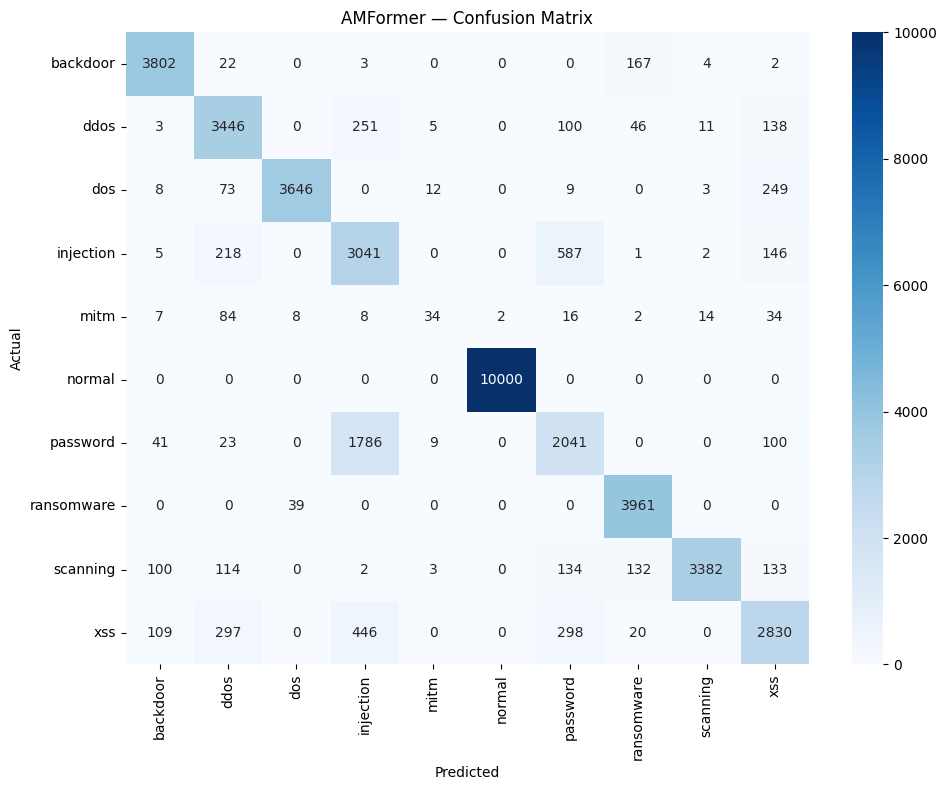

Saved: /content/drive/MyDrive/toniot_outputs/amformer_cm.png


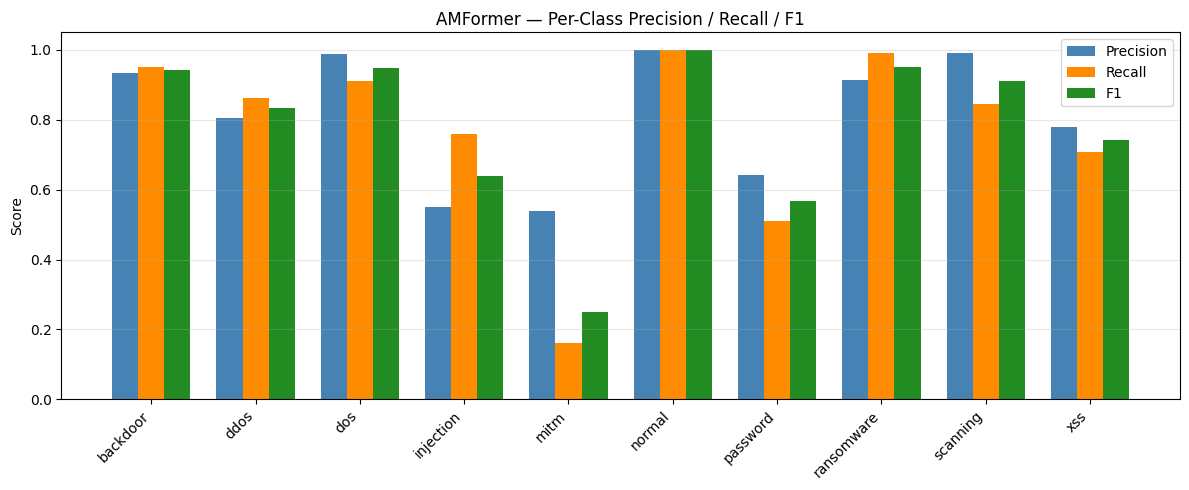

Saved: /content/drive/MyDrive/toniot_outputs/amformer_prf.png


In [9]:
# AMFormer TEST EVALUATION

model.eval()
all_preds, all_true, all_proba = [], [], []
t0 = time.time()

with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb.to(DEVICE))
        proba  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
        all_proba.append(proba)

infer_time = time.time() - t0
all_proba = np.concatenate(all_proba, axis=0)

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

amformer_results = evaluate(
    "AMFormer", y_test, np.array(all_preds),
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR,
    y_proba=all_proba
)

  TABLE 1: Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.8572
Precision (macro) 0.8140
   Recall (macro) 0.7700
       F1 (macro) 0.7783
    F1 (weighted) 0.8572
              MCC 0.8372
    Cohen's Kappa 0.8362
  ROC-AUC (macro) 0.9764



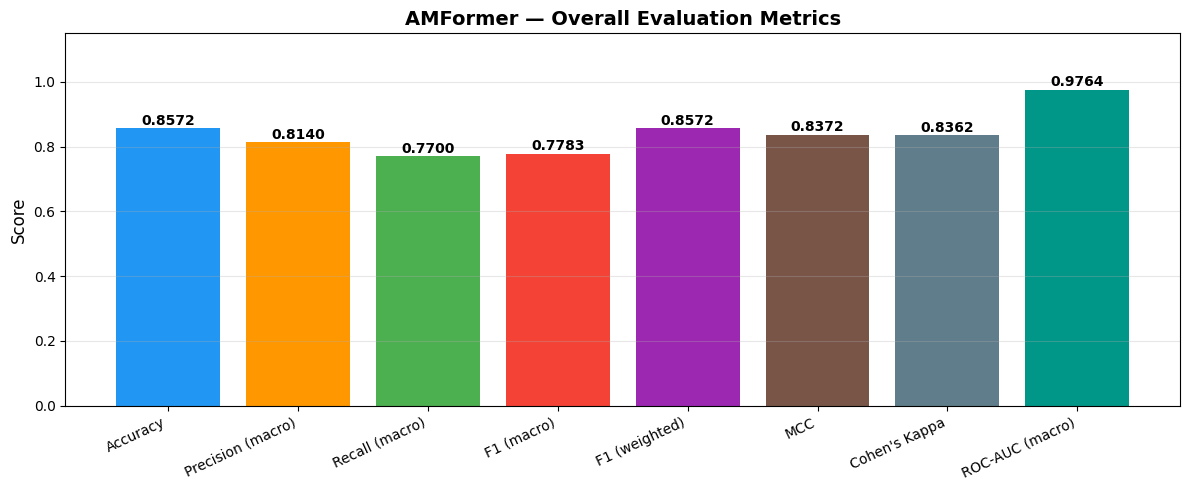

  TABLE 2: Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9330  0.9505    0.9417     4000
      ddos     0.8057  0.8615    0.8327     4000
       dos     0.9873  0.9115    0.9479     4000
 injection     0.5492  0.7602    0.6377     4000
      mitm     0.5397  0.1627    0.2500      209
    normal     0.9998  1.0000    0.9999    10000
  password     0.6408  0.5102    0.5681     4000
ransomware     0.9150  0.9902    0.9511     4000
  scanning     0.9900  0.8455    0.9121     4000
       xss     0.7792  0.7075    0.7416     4000



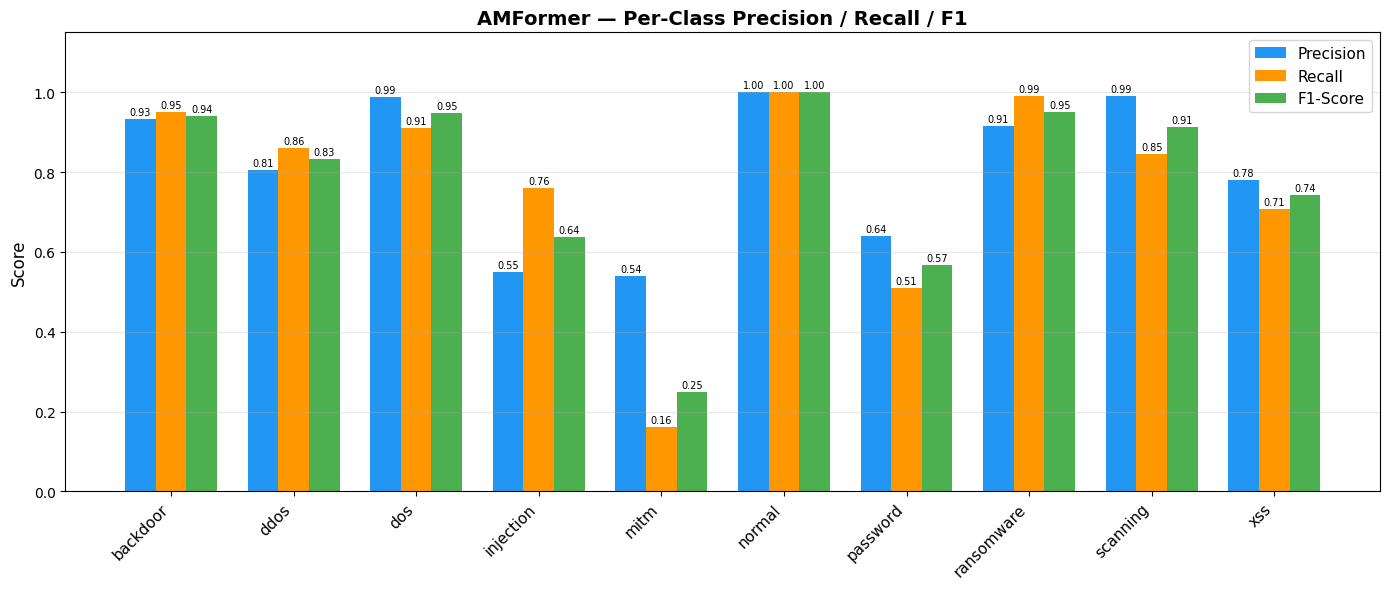

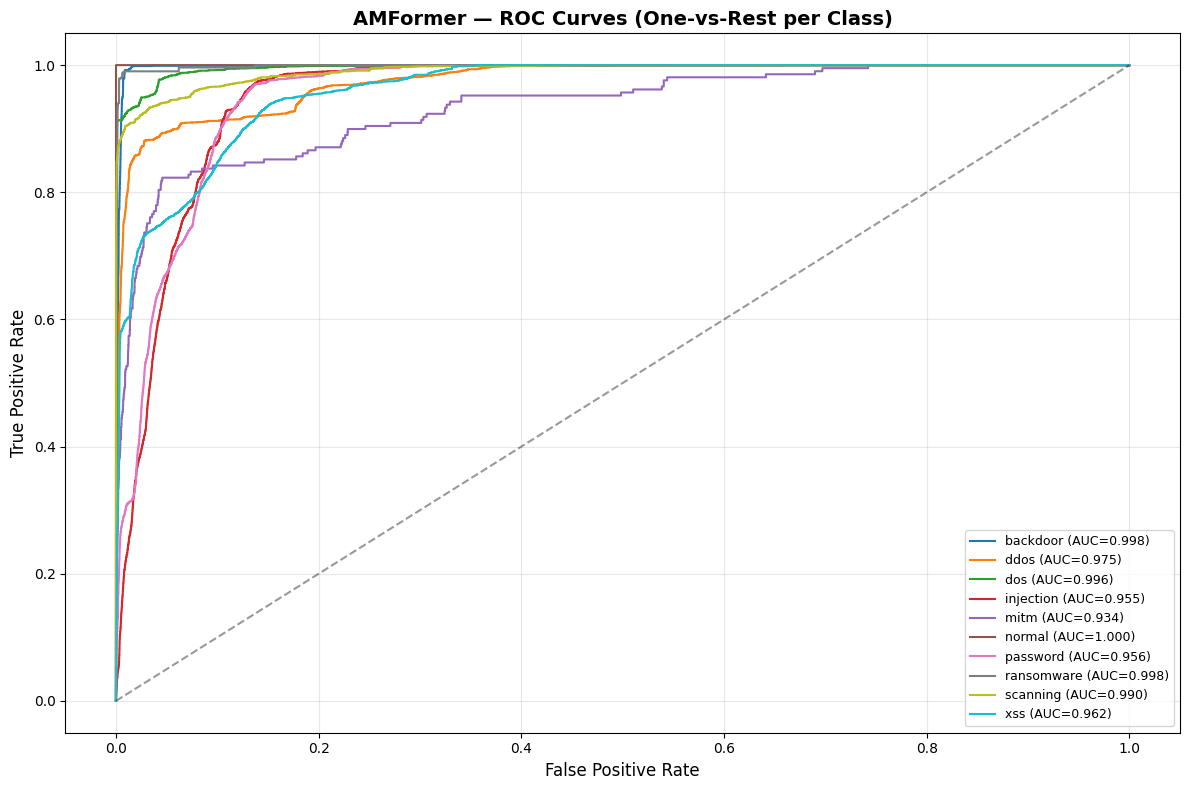

  TABLE 3: Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   0.9976
      ddos   0.9755
       dos   0.9957
 injection   0.9547
      mitm   0.9338
    normal   1.0000
  password   0.9564
ransomware   0.9985
  scanning   0.9905
       xss   0.9617

  Macro-average ROC-AUC: 0.9764

  TABLE 4: MCC & Cohen's Kappa Interpretation
                                Metric  Score Interpretation
MCC (Matthews Correlation Coefficient) 0.8372         Strong
                         Cohen's Kappa 0.8362 Almost Perfect


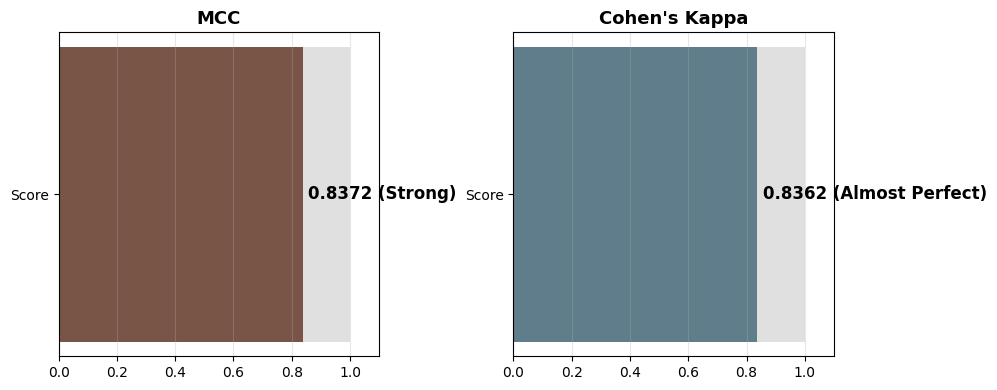

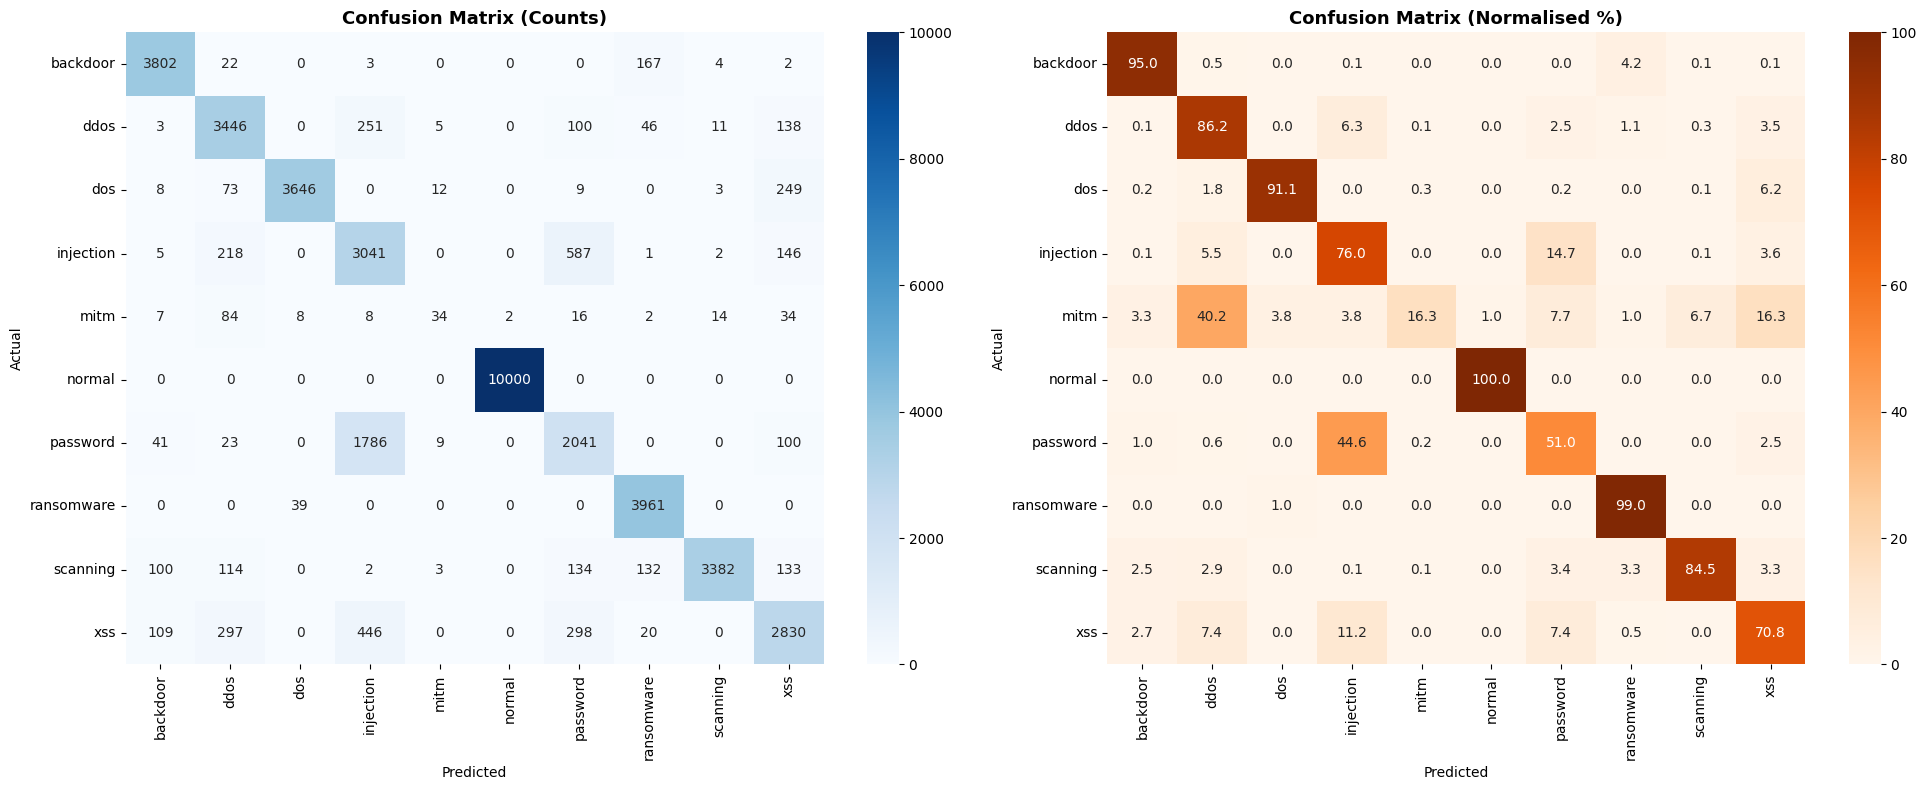


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [10]:
# COMPREHENSIVE METRICS WITH TABLES & VISUALISATIONS

from sklearn.metrics import (
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef, precision_recall_curve,
    roc_curve, auc
)

y_true = y_test
y_pred = np.array(all_preds)
y_prob = all_proba

label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART


acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except:
    roc_auc = None

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

# Bar chart for macro metrics
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336",
          "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("AMFormer — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "amformer_macro_metrics.png"), dpi=150)
plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART


prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names,
    "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4),
    "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})

print("=" * 60)
print("  TABLE 2: Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names))
w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
# Add value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("AMFormer — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "amformer_perclass_prf.png"), dpi=150)
plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES


from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

auc_per_class = []
fig, ax = plt.subplots(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class.append(class_auc)
    ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("AMFormer — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "amformer_roc_curves.png"), dpi=150)
plt.show()

roc_df = pd.DataFrame({
    "Class": label_names,
    "ROC-AUC": np.round(auc_per_class, 4)
})
print("=" * 60)
print("  TABLE 3: Per-Class ROC-AUC")
print("=" * 60)
print(roc_df.to_string(index=False))
if roc_auc:
    print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")


# 4. MCC & COHEN'S KAPPA — INTERPRETATION TABLE


def interpret_mcc(val):
    if val >= 0.9: return "Excellent"
    if val >= 0.7: return "Strong"
    if val >= 0.5: return "Moderate"
    if val >= 0.3: return "Weak"
    return "Poor"

def interpret_kappa(val):
    if val >= 0.81: return "Almost Perfect"
    if val >= 0.61: return "Substantial"
    if val >= 0.41: return "Moderate"
    if val >= 0.21: return "Fair"
    return "Slight/Poor"

agreement_df = pd.DataFrame({
    "Metric": ["MCC (Matthews Correlation Coefficient)",
               "Cohen's Kappa"],
    "Score": [round(mcc, 4), round(kappa, 4)],
    "Interpretation": [interpret_mcc(mcc), interpret_kappa(kappa)]
})

print()
print("=" * 60)
print("  TABLE 4: MCC & Cohen's Kappa Interpretation")
print("=" * 60)
print(agreement_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric_name, value, interp, color in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B"),
]:
    ax.barh(["Score"], [value], color=color, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(value + 0.02, 0, f"{value:.4f} ({interp})",
            va="center", fontsize=12, fontweight="bold")
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "amformer_mcc_kappa.png"), dpi=150)
plt.show()


# 5. CONFUSION MATRIX (NORMALISED %)


cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "amformer_cm_dual.png"), dpi=150)
plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

In [11]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

model.eval()
train_preds_all = []
with torch.no_grad():
    for xb, yb in train_dl:
        preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
        train_preds_all.extend(preds)

# Adjust for drop_last in training DataLoader
y_train_trimmed = y_train[:len(train_preds_all)]
amformer_train_acc = accuracy_score(y_train_trimmed, train_preds_all)
amformer_train_f1  = f1_score(y_train_trimmed, train_preds_all, average="macro", zero_division=0)

print("=" * 50)
print("AMFormer — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {amformer_train_acc:.4f}")
print(f"  Test  Acc    : {amformer_results['accuracy']:.4f}")
print(f"  Train F1     : {amformer_train_f1:.4f}")
print(f"  Test  F1     : {amformer_results['f1_macro']:.4f}")
print()

acc_gap = amformer_train_acc - amformer_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif amformer_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

AMFormer — Train vs Test Diagnosis
  Train Acc    : 0.1278
  Test  Acc    : 0.8572
  Train F1     : 0.0989
  Test  F1     : 0.7783

  Generalisation gap: -0.7295 — model generalises well

  Training time : 607.0s
  Inference time: 1.58s (42,209 samples)


In [12]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "AMFormer",
    "paper"           : "AAAI 2024 — Cheng et al.",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : amformer_train_acc,
    "train_f1"        : amformer_train_f1,
    "train_time_s"    : round(train_time, 2),
    "infer_time_s"    : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "amformer_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                        0
model                            AMFormer
paper            AAAI 2024 — Cheng et al.
dataset                   TON-IoT Network
train_samples                      147729
test_samples                        42209
n_features                             17
n_classes                              10
accuracy                         0.857234
f1_macro                          0.77828
f1_weighted                      0.857231
precision_macro                  0.813972
recall_macro                     0.769993
mcc                              0.837246
cohen_kappa                      0.836218
roc_auc_macro                    0.976433
train_acc                        0.127767
train_f1                         0.098949
train_time_s                       607.03
infer_time_s                       1.5821

Results saved to: /content/drive/MyDrive/toniot_outputs/amformer_toniot_results.csv
